In [1]:
from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableParallel
from typing import TypedDict, Literal, Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import pandas as pd
import os
import re
import json
import ast
from get_coordinates import get_city_coordinates
from air_quality import (
    get_current_air_quality,
    get_forecast_air_quality,
    clean_air_quality_data, 
    plot_air_quality_data
)
from weather import (
    get_current_weather,
    get_forecast_weather,
    clean_current_weather_data,
    clean_forecast_weather_data,
    plot_temperature_data,
    plot_rain_data,
    plot_wind_data
)
load_dotenv()

True

In [2]:
model = ChatOllama(
    model="deepseek-r1:1.5b",
    temperature=0.6,
    reasoning=True
)

In [3]:
from langchain.prompts import PromptTemplate, FewShotPromptTemplate
from langchain.prompts.example_selector import SemanticSimilarityExampleSelector
from langchain.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# -------------------------------
# Step 1. Parse Example
# -------------------------------
def escape_braces(s: str) -> str:
    return s.replace("{", "{{").replace("}", "}}")
    
# -------------------------------
# Step 1. Define your examples
# -------------------------------
examples = [
    {"query": "What is weather in Delhi, India today?",
     "output": escape_braces('{"query_type": "current", "city_name": "Delhi", "country_code": "IN"}')},
    
    {"query": "Weather of Pune, India for next 3 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}')},
    
    {"query": "Show weather in London UK now",
     "output": escape_braces('{"query_type": "current", "city_name": "London", "country_code": "GB"}')},
    
    {"query": "Forecast for Paris, France for 7 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}')},
]

# -------------------------------
# Step 2. Set up embeddings + selector
# -------------------------------
embeddings = OllamaEmbeddings(model="mxbai-embed-large:latest")

example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples=examples,
    embeddings=embeddings,
    vectorstore_cls=FAISS,
    k=3,
    input_keys=["query"]   # match user query
)

# -------------------------------
# Step 3. Define the example prompt format
# -------------------------------
example_prompt = PromptTemplate(
    query_variables=["query", "output"],
    template="User query: {query}\nOutput: {output}\n"
)

# -------------------------------
# Step 4. Build the few-shot prompt
# -------------------------------
few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=example_prompt,
    prefix="Extract structured weather info as JSON with keys: query_type, city_name, country_code, days (if forecast).\n\n",
    suffix="User query: {query}\nOutput:",
    input_variables=["query"]
)

# -------------------------------
# Step 5. Try it with a query
# -------------------------------
user_query = "Forecast for Paris, France for 7 days"

formatted_prompt = few_shot_prompt.format(query=user_query)
print(formatted_prompt)

Extract structured weather info as JSON with keys: query_type, city_name, country_code, days (if forecast).



User query: Forecast for Paris, France for 7 days
Output: {"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}


User query: Show weather in London UK now
Output: {"query_type": "current", "city_name": "London", "country_code": "GB"}


User query: Weather of Pune, India for next 3 days
Output: {"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}


User query: Forecast for Paris, France for 7 days
Output:


In [4]:
class WeatherQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the weather query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")
    days: Optional[int] = Field(
        7, description="This field is required when using forecast"
    )
    
def get_weather_query_inputs(user_prompt: str, model, few_shot_prompt: FewShotPromptTemplate) -> Optional[WeatherQuerySchema]:
    # Format the prompt with few-shot examples using the example selector
    prompt = few_shot_prompt.format(query=user_prompt)
    
    # Invoke the model with the formatted prompt
    result = model.invoke(prompt)
    text = result.content.strip()
    
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            try:
                data = json.loads(match.group())
            except json.JSONDecodeError as e:
                print(f"JSON decode error after regex extraction: {e}")
                return None
        else:
            print("No JSON object found in the model output.")
            return None

    try:
        return WeatherQuerySchema(**data)
    except Exception as e:
        print(f"Schema validation error: {e}")
        return None

user_prompt = "What is weather of London, United Kingdom"
schema = get_weather_query_inputs(user_prompt, model, few_shot_prompt)
schema

WeatherQuerySchema(query_type='current', city_name='London', country_code='GB', days=7)

In [5]:
from typing import TypedDict, Literal
import pandas as pd

# -----------------------------
# State Definition
# -----------------------------
class WeatherWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    days: int
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    plot_temperature: str
    plot_rain: str
    plot_wind: str

# -----------------------------
# Node Functions
# -----------------------------
def start_weather_graph(state: WeatherWFState) -> WeatherWFState:
    # Use LLM to extract structured inputs
    user_prompt = state["user_prompt"]
    schema = get_weather_query_inputs(user_prompt, model, few_shot_prompt)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name.upper(),
        "country_code": schema.country_code.upper(),
        "days": schema.days
    }

def route_weather_query(state: WeatherWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_weather"
    elif state['query_type'] == "forecast":
        return "run_forecast_weather"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")

def run_current_weather(state: WeatherWFState) -> WeatherWFState:
    data = get_current_weather(state["city_name"], state["country_code"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_weather(state: WeatherWFState) -> WeatherWFState:
    data = get_forecast_weather(state["city_name"], state["country_code"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_weather_response(state: WeatherWFState) -> WeatherWFState:
    if state['query_type'] == "current":
        df = clean_current_weather_data(state['raw_data'])
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_forecast_weather_data(state["raw_data"].get("list"))
        return {**state, "df": df}
    else:
        raise ValueError(f"Invalid query_type for cleaning: {state['query_type']}")

def plot_forecast_weather(state: WeatherWFState) -> WeatherWFState:
    if state.get("make_plot"):
        plot_runner = RunnableParallel(
            temperature=lambda s: plot_temperature_data(s["df"], return_base64=True),
            rain=lambda s: plot_rain_data(s["df"], return_base64=True),
            wind=lambda s: plot_wind_data(s["df"], return_base64=True),
        )
        plot_dict = plot_runner.invoke(state)
        return {
            **state, 
            "plot_temperature": plot_dict.get("temperature"),
            "plot_rain": plot_dict.get("rain"),
            "plot_wind": plot_dict.get("wind")
        }
    return state

# -----------------------------
# Graph Definition
# -----------------------------
weather_graph = StateGraph(WeatherWFState)

weather_graph.add_node("start_weather_graph", start_weather_graph)
weather_graph.add_node("run_current_weather", run_current_weather)
weather_graph.add_node("run_forecast_weather", run_forecast_weather)
weather_graph.add_node("clean_weather_response", clean_weather_response)
weather_graph.add_node("plot_forecast_weather", plot_forecast_weather)

weather_graph.set_entry_point("start_weather_graph")

# conditional routing
weather_graph.add_conditional_edges(
    "start_weather_graph",
    route_weather_query,
    {
        "run_current_weather": "run_current_weather",
        "run_forecast_weather": "run_forecast_weather"
    }
)

# shared cleaning stage
weather_graph.add_edge("run_current_weather", "clean_weather_response")
weather_graph.add_edge("run_forecast_weather", "clean_weather_response")

# plotting + end
weather_graph.add_edge("clean_weather_response", "plot_forecast_weather")
weather_graph.add_edge("plot_forecast_weather", END)

weather_graph_wf = weather_graph.compile()

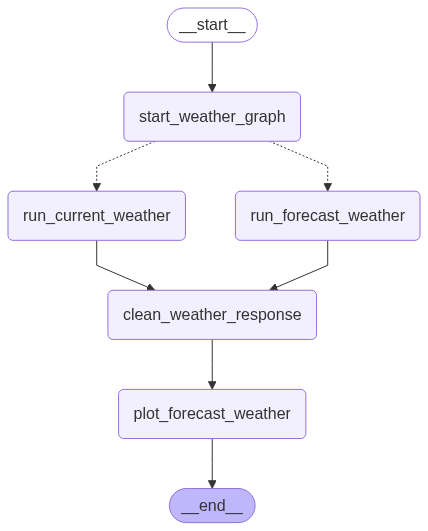

In [6]:
weather_graph_wf

AttributeError: 'numpy.ndarray' object has no attribute 'set_ylabel'

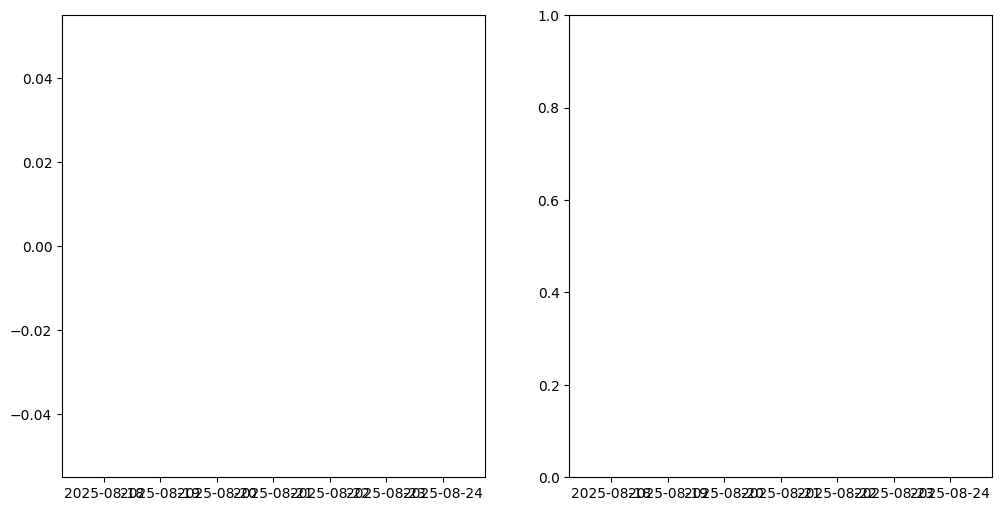

In [10]:
input_prompt = {"user_prompt": "What is Weather of San Francisco, USA for next weekened"}
output = weather_graph_wf.invoke(input_prompt)
output

In [ ]:
import base64
import io
from PIL import Image
import matplotlib.pyplot as plt

def show_base64_image(img_base64: str):
    """Display a base64 image string with matplotlib."""
    # Remove prefix if present ("data:image/png;base64,...")
    if img_base64.startswith("data:image"):
        img_base64 = img_base64.split(",")[1]
    
    # Decode base64 -> bytes
    img_bytes = base64.b64decode(img_base64)
    
    # Load as image
    img = Image.open(io.BytesIO(img_bytes))
    
    # Plot
    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
show_base64_image(output['plot_temperature'])

In [ ]:
show_base64_image(output['plot_rain'])

In [ ]:
show_base64_image(output['plot_wind'])